# Generate Responsed Signal from Different Sources

In [ ]:
import time
import numpy as np
import matplotlib.pyplot as plt

from gwspace.response import get_y_slr_td, trans_y_slr_fd, get_XYZ_td, tdi_XYZ2AET
from gwspace.Orbit import detectors
from gwspace.constants import DAY, YRSID_SI, MONTH

try:
    import cupy as cp
except Exception:
    cp = None

from gwspace.Waveform import waveforms
from gwspace.Waveform import waveforms
from gwspace.response_b import (
    get_y_slr_td,
    get_XYZ_td,
    get_AET_td,
    tdi_XYZ2AET,
)

GWSpace supports generating waveforms of multiple sources, each kind of sources has its own class to store source parameters. These classes can be called either directly or through the dictionary `Waveform.waveforms`:

In [4]:
print(waveforms)

{'burst': <class 'gwspace.Waveform.BurstWaveform'>, 'bhb_PhenomD': <class 'gwspace.Waveform.BHBWaveform'>, 'bhb_EccFD': <class 'gwspace.Waveform.BHBWaveformEcc'>, 'gcb': <class 'gwspace.Waveform.GCBWaveform'>, 'emri': <class 'gwspace.Waveform.EMRIWaveform'>, 'ringdown': <class 'gwspace.Waveform.RingdownWaveform'>}


## Galaxy Compact Binary (GCB)

GWSpace provides a simple analytical expression of time-domain GCB waveform under small frequency evolution approximation.

In [6]:
GCBpars = {"mass1": 0.5,
           "mass2": 0.5,
           "DL": 0.3,
           "phi0": 0.0,
           "f0": 0.001,
           "psi": 0.2,
           "iota": 0.3,
           "Lambda": 0.4,
           "Beta": 1.2,
           "T_obs": 10*DAY,  # YRSID_SI / 4
           }

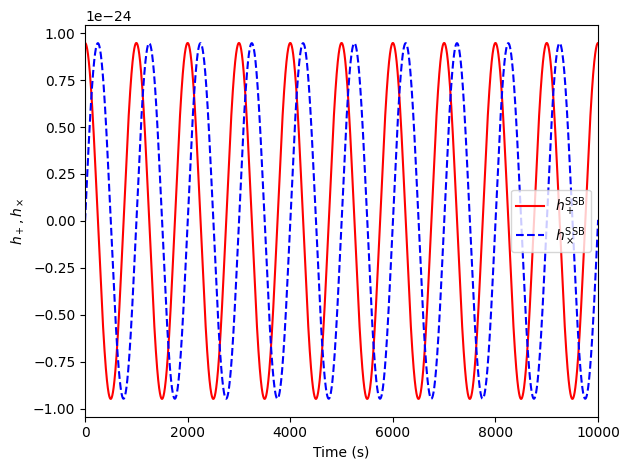

In [4]:
delta_t = 1.
tf = np.arange(0, GCBpars['T_obs'], delta_t)

GCBwf = waveforms['gcb'](**GCBpars)
hpssb, hcssb = GCBwf.get_hphc(tf)

plt.figure()
plt.plot(tf, hpssb, 'r-', label=r'$h_+^{\rm SSB}$')
plt.plot(tf, hcssb, 'b--', label=r'$h_\times^{\rm SSB}$')
plt.xlabel("Time (s)")
plt.ylabel(r"$h_+, h_\times$")
plt.xlim(0, 10000)  # let's zoom into a small range
plt.legend(loc="best")
plt.tight_layout()

In [5]:
def generate_td_data(pars, t_array, s_type='gcb', det='TQ', show_y_slr=False):
    print(f"Generating {s_type} waveforms")
    wf = waveforms[s_type](**pars)
    if show_y_slr:
        # Here is the example of how to check single arm response
        st = time.time()
        y_slr = get_y_slr_td(wf, t_array, det)
        ed = time.time()
        print(f"Time cost: {ed-st:.3f}s for {tf.shape[0]} points")

        tags = [(1, 2), (2, 1), (1, 3), (3, 1), (2, 3), (3, 2)]
        for i, tag in enumerate(tags):
            plt.figure()
            for j in range(4):
                plt.subplot(4, 1, j+1)
                plt.plot(tf, y_slr[tag][j])
                plt.title(f"y_{tag} [{j}]L")

    st = time.time()
    X, Y, Z = get_XYZ_td(wf, tf, det)
    A, E, T = tdi_XYZ2AET(X, Y, Z)
    # You can directly use get_AET_td() if you want AET channel only
    ed = time.time()
    print(f"Time cost of calculating XYZ and AET with y_slr: {ed-st:.3f}s")

    plt.subplots(2, 3, sharex='all', sharey='all')
    for i, (d, label) in enumerate(zip((X, Y, Z, A, E, T), "XYZAET")):
        plt.subplot(2, 3, i+1)
        plt.plot(tf[:-5], d[:-5])
        plt.xlabel("Time (s)")
        plt.ylabel("h")
        plt.title(label)
    plt.tight_layout()

Generating gcb waveforms
Time cost of calculating XYZ and AET with y_slr: 2.449s


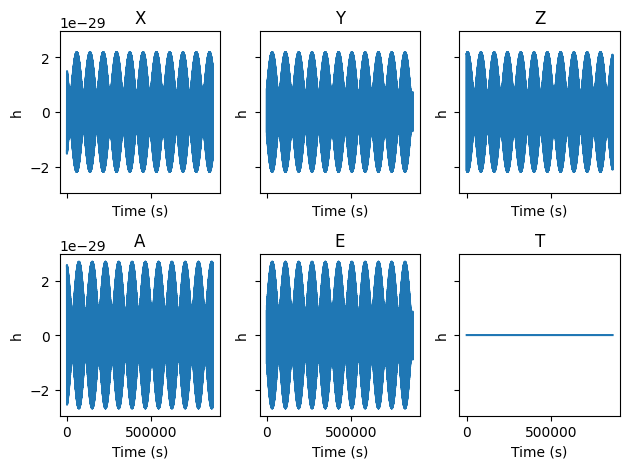

In [6]:
generate_td_data(GCBpars, tf, show_y_slr=False)

### FastGB: GCB waveform from fast/slow decomposition

GWSpace also adopt FastGB from `Galaxy` in the Mock LISA Data Challenge (MLDC). It uses a fast/slow decomposition of the waveform to reduce the computational cost, see arXiv:0704.1808 for more details.

Now take J0806 (Orientation of TianQin detector orbit) as an example:

In [8]:
def generate_fastgb(dt=1., oversample=1, show_td=False):
    # dt = 15.  # 1s for TianQin, 15s for LISA
    pars = {"mass1": 0.5,
            "mass2": 0.5,
            'T_obs': YRSID_SI*2,
            "phi0": 3.1716561,
            "f0": 0.00622028,
            "fdot": 7.48528554e-16,
            "psi": 2.91617795,
            "iota": 0.645772,
            "Lambda": 2.10225,  # ecliptic longitude [rad] J0806
            "Beta": -0.082205,  # ecliptic latitude [rad]
            }
    fastB = waveforms['gcb'](**pars)

    st = time.time()
    f, X, Y, Z = fastB.get_fastgb_fd_single(dt, oversample, detector='TianQin')
    ed = time.time()
    print(f"time cost is {ed-st}s")

    plt.figure()
    plt.loglog(f, np.abs(X), label='X')
    plt.loglog(f, np.abs(Y), label='Y')
    plt.loglog(f, np.abs(Z), label='Z')
    plt.xlim(0.00620, 0.00624)
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('h')
    plt.tight_layout()

    if show_td:
        st = time.time()
        t, X, Y, Z = fastB.get_fastgb_td(dt, oversample, detector='TianQin')
        ed = time.time()
        print(f"time cost is {ed-st}s")

        plt.figure()
        plt.plot(t, X, label='X')
        plt.plot(t, Y, label='Y')
        plt.plot(t, Z, label='Z')
        plt.tight_layout()

time cost is 0.0018646717071533203s


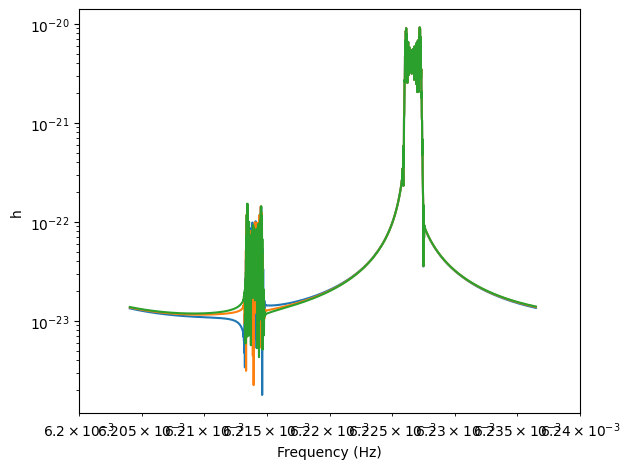

In [9]:
generate_fastgb()

## Extreme Mass Ratio Inspiral (EMRI)

GWSpace uses [FastEMRIWaveforms](https://github.com/BlackHolePerturbationToolkit/FastEMRIWaveforms) for EMRI. However, **you need to install it manually.**

In [5]:
EMRIpars = {'M': 1e6,  # Mass of larger black hole in solar masses
            'mu': 1e1,  # Mass of compact object in solar masses
            'a': 0.1,  # Dimensionless spin of massive black hole, will be ignored in Schwarzschild waveform
            'p0': 12.0,
            'e0': 0.2,
            'x0': 1.0,  # will be ignored in Schwarzschild waveform
            'qS': 0.3,  # polar sky angle
            'phiS': 0.3,  # azimuthal viewing angle
            'qK': 0.2,  # polar spin angle
            'phiK': 0.2,  # azimuthal viewing angle
            'dist': 1.0,  # Luminosity distance in Gpc
            'Phi_phi0': 1.0,
            'Phi_theta0': 2.0,
            'Phi_r0': 3.0,
            'psi': 0.4,
            'iota': 0.2,
            'T_obs': MONTH,
            }

TypeError: Implicit conversion to a NumPy array is not allowed. Please use `.get()` to construct a NumPy array explicitly.

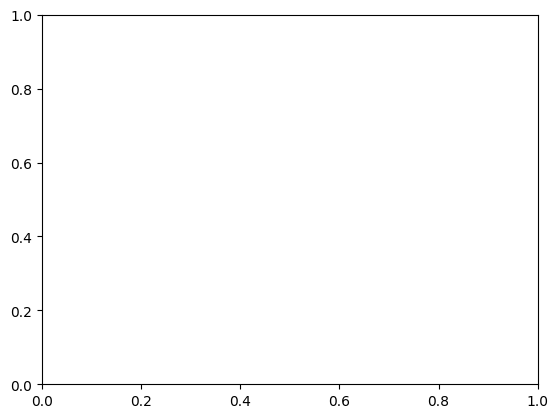

In [6]:
delta_t = 15.  # seconds
tf = np.arange(0, EMRIpars['T_obs'], delta_t)

EMRIwf = waveforms['emri'](**EMRIpars)
hp, hc = EMRIwf.get_hphc(tf)

index = 2000
plt.figure()
plt.plot(tf[:index], hp[:index])
plt.plot(tf[:index], hc[:index])
plt.xlabel('Time (s)')
plt.ylabel('h')
plt.tight_layout()

Generating emri waveforms
Time cost of calculating XYZ and AET with y_slr: 4.667s


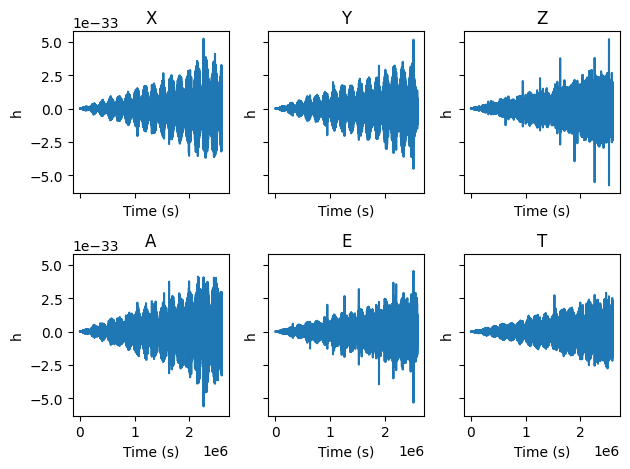

In [5]:
generate_td_data(EMRIpars, tf, s_type='emri')

## Binary Black Hole (BBH)

GWSpace supports two frequency-domain BBH waveform: IMRPhenomD and EccentricFD.


### IMRPhenomD

In [13]:
MBHBpars = {"mass1": 3.5e6,
            "mass2": 2.1e5,
            'T_obs': MONTH*3,
            "chi1": 0.2,
            "chi2": 0.1,
            "DL": 1e3,
            "psi": 0.2,
            "iota": 0.3,
            "Lambda": 0.4,
            "Beta": 1.2,
            "tc": 0,
            }

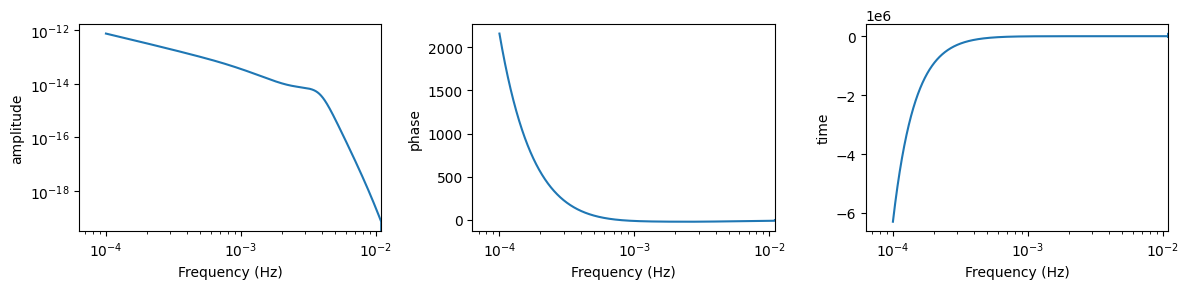

In [14]:
NF = 10240
freq = np.logspace(-4, 0, NF)

BHBwf = waveforms['bhb_PhenomD'](**MBHBpars)
amp, phase, tf = BHBwf.get_amp_phase(f_series=freq)
i_max = np.where(amp[(2, 2)] == 0)[0][0]

plt.subplots(1, 3, sharex='all', figsize=(12, 3))
plt.subplot(1, 3, 1)
plt.loglog(freq, amp[(2, 2)])
plt.xlabel('Frequency (Hz)')
plt.ylabel('amplitude')

plt.subplot(1, 3, 2)
plt.semilogx(freq, phase[(2, 2)])
plt.xlabel('Frequency (Hz)')
plt.ylabel('phase')

plt.subplot(1, 3, 3)
plt.semilogx(freq, tf[(2, 2)])
plt.xlabel('Frequency (Hz)')
plt.ylabel('time')

plt.xlim(None, freq[i_max])
plt.tight_layout()

In [15]:
def generate_fd_data(pars, f_array, s_type='bhb_PhenomD', det='TQ', show_y_slr=False):
    print(f"Generating {s_type} waveforms")
    wf = waveforms[s_type](**pars)

    if show_y_slr:
        # Here is the example of how to check single arm response
        amp, phase, tf = wf.get_amp_phase(f_series=f_array)
        amp, phase, tf = amp[(2, 2)], phase[(2, 2)], tf[(2, 2)]
        h22 = amp * np.exp(1j*phase) * np.exp(2j*np.pi*f_array*wf.tc)
        det_orb = detectors[det](tf)

        st = time.time()
        y_slr = trans_y_slr_fd(wf.vec_k, wf.p_22, det_orb, f_array)[0]
        y_slr = {k: v*h22 for k, v in y_slr.items()}
        ed = time.time()
        print(f"Time cost for the fd response: {ed-st:.4f}s")

        ln = [(1, 2), (2, 1), (1, 3), (3, 1), (2, 3), (3, 2)]
        plt.figure()
        for ll in ln:
            plt.loglog(freq, np.abs(y_slr[ll]), label=ll)
        plt.xlabel('Frequency (Hz)')
        plt.ylabel('h')
        plt.legend()
        plt.tight_layout()

    X, Y, Z = wf.get_tdi_response(f_series=f_array, channel='XYZ', det=det)
    A, E, T = wf.get_tdi_response(f_series=f_array, channel='AET', det=det)

    plt.figure()
    plt.loglog(f_array, np.abs(X), '-', label='X')
    plt.loglog(f_array, np.abs(Y), '-', label='Y')
    plt.loglog(f_array, np.abs(Z), '-', label='Z')
    plt.loglog(f_array, np.abs(A), '--', label='A')
    plt.loglog(f_array, np.abs(E), '--', label='E')
    plt.loglog(f_array, np.abs(T), '--', label='T')
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('h')
    plt.legend()
    plt.tight_layout()

Generating bhb_PhenomD waveforms
Time cost for the fd response: 0.2561s


/tmp/ipykernel_20053/1365978856.py:21: MatplotlibDeprecationWarning: Passing label as a length 2 sequence when plotting a single dataset is deprecated in Matplotlib 3.9 and will error in 3.11.  To keep the current behavior, cast the sequence to string before passing.
  plt.loglog(freq, np.abs(y_slr[ll]), label=ll)


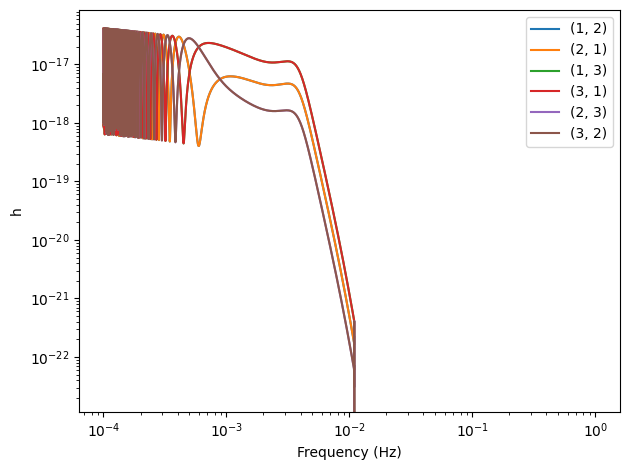

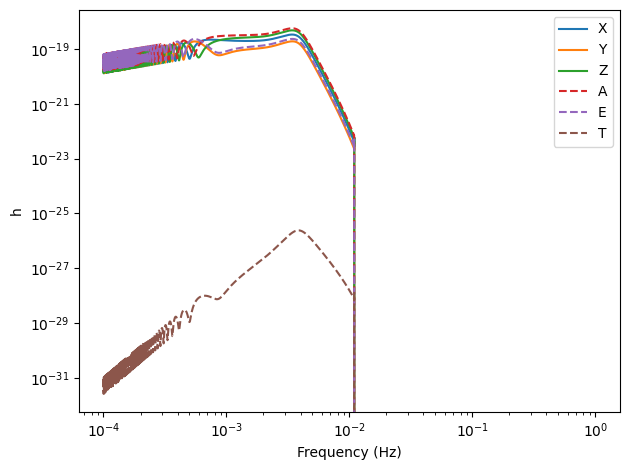

In [16]:
generate_fd_data(MBHBpars, freq, show_y_slr=True)

### EccentricFD

GWSpace also supports a [modified version](https://github.com/HumphreyWang/pyEccentricFD) of EccentricFD waveform, which is specially for space-detector responses.

Since EccentricFD is an eccentric non-spinning inspiral-only waveform, it'd better be used for stellar-mass BBHs, which will merge outside the sensitive frequency band of space detectors.

In [17]:
ecc_pars = {'DL': 100,  # Luminosity distance (Mpc)
            'mass1': 35.6,  # Primary mass (solar mass)
            'mass2': 30.6,  # Secondary mass(solar mass)
            'Lambda': 4.7,  # Longitude
            'Beta': -1.5,  # Latitude
            'phi_c': 0,  # Coalescence phase
            'T_obs': MONTH*3,  # Observation time (s)
            'tc': 0,  # Coalescence time (s)
            'iota': 0.3,  # Inclination angle
            'var_phi': 0,  # Observer phase
            'psi': 0.2,  # Polarization angle
            }  # masses of GW150914

Finished in  0.47977s 



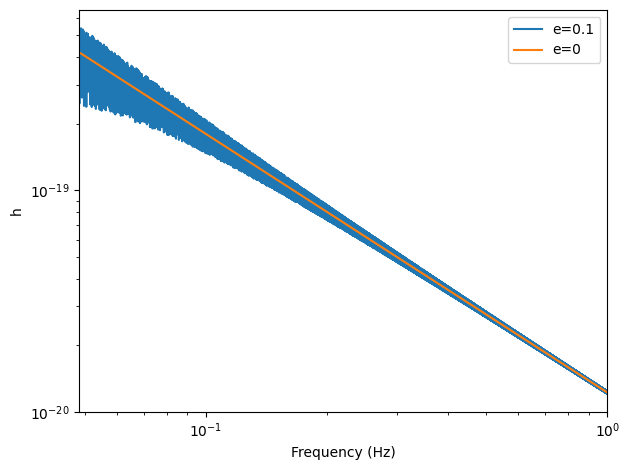

In [18]:
start_time = time.time()
delta_f = 1e-5
ecc_wf = waveforms['bhb_EccFD'](**ecc_pars, eccentricity=0.1)
hp, _ = ecc_wf.get_hphc(delta_f=delta_f)
ecc_wf0 = waveforms['bhb_EccFD'](**ecc_pars, eccentricity=0.)
hp0, _ = ecc_wf0.get_hphc(delta_f=delta_f)
print(f'Finished in {time.time() - start_time: .5f}s', '\n')

freq = delta_f * np.array(range(len(hp)))
plt.figure()
plt.loglog(freq, np.abs(hp), label='e=0.1')
plt.loglog(freq, np.abs(hp0), label='e=0')
plt.xlim(ecc_wf.f_min, 1)
plt.xlabel('Frequency (Hz)')
plt.ylabel('h')
plt.legend()
plt.tight_layout()

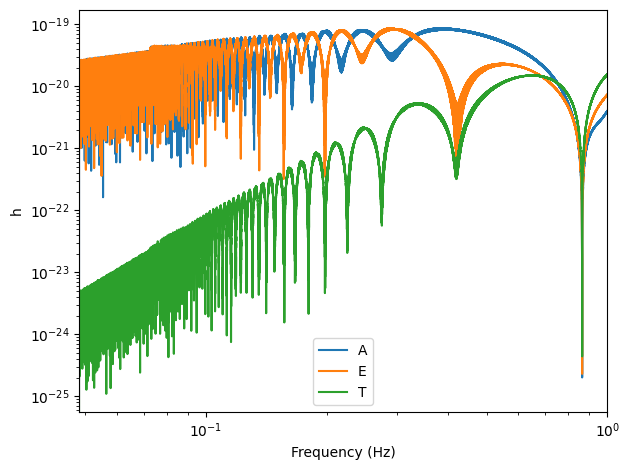

In [19]:
(smBBH_A, smBBH_E, smBBH_T), freq_e = ecc_wf.get_tdi_response(delta_f=delta_f, det='TQ')

plt.figure()
plt.loglog(freq_e, np.abs(smBBH_A), label='A')
plt.loglog(freq_e, np.abs(smBBH_E), label='E')
plt.loglog(freq_e, np.abs(smBBH_T), label='T')
plt.xlabel('Frequency (Hz)')
plt.ylabel('h')
plt.xlim(ecc_wf.f_min, 1)
# plt.ylim(1e-23, 1e-16)
plt.legend()
plt.tight_layout()

## GW Burst

GWSpace provides a sin-Gaussian waveform as basic model of bursts.

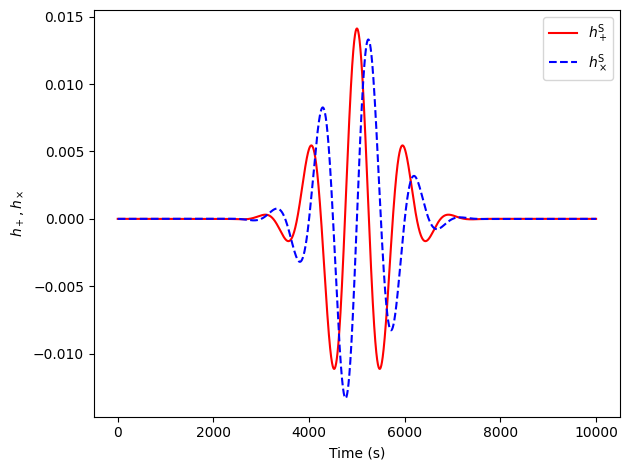

In [20]:
T_obs = 10000  # YRSID_SI / 4
delta_t = 1
tf = np.arange(0, T_obs, delta_t)

Burst = waveforms['burst'](amp=0.5, tau=1000, fc=0.001, tc=5000)
hp, hc = Burst.get_hphc(tf)

plt.figure()
plt.plot(tf, hp, 'r-', label=r'$h_+^{\rm S}$')
plt.plot(tf, hc, 'b--', label=r'$h_\times^{\rm S}$')
plt.xlabel("Time (s)")
plt.ylabel(r"$h_+, h_\times$")
plt.legend()
plt.tight_layout()

# TODO: add results after response?

## Stochastic Gravitational Wave Background (SGWB)

GWSpace also supports isotropy SGWB and SGWB from a specific orientation.

Time cost: 3.728898286819458 s
1 year SNR for SGWB: 7.463296725560229


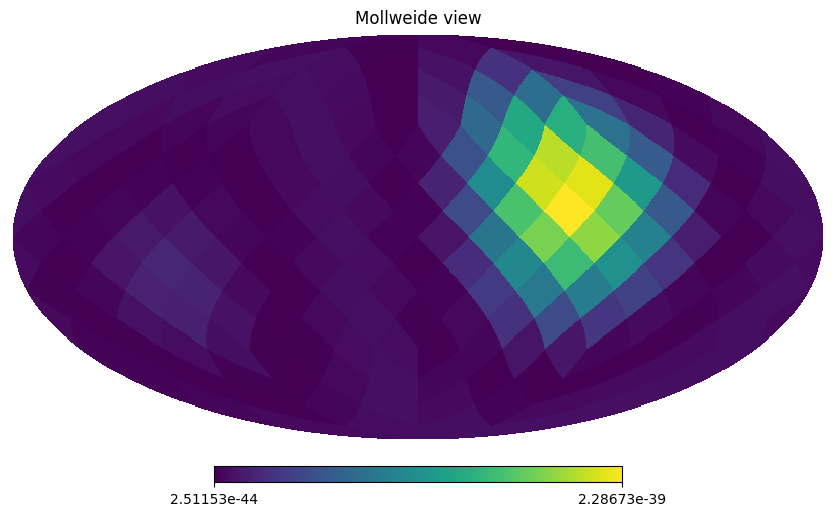

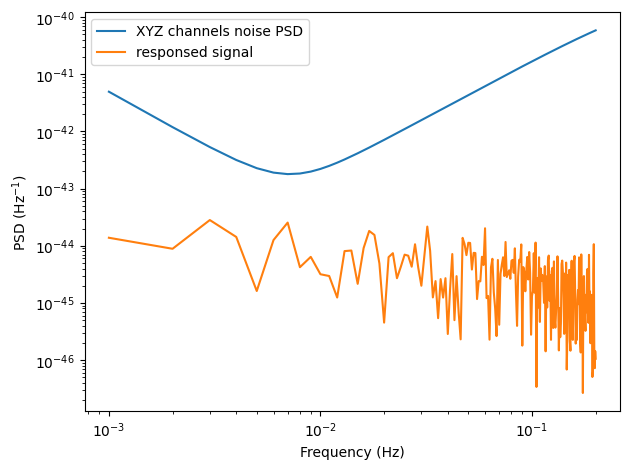

In [21]:
import healpy as hp
from gwspace.SGWB import SGWB
from gwspace.Noise import TianQinNoise

SGWBpars = {"nside": 4,
            "omega0": 5e-11,
            "alpha": 0.667,
            "T_obs": 63*5000,
            # "blm_vals": (1.0, 0.75, 0.5, 0.7j, 0.7-0.3j, 1.1j),
            # "blmax": 2,
            "theta": 1.3,
            "phi": 1.2,
            }
signal_pars = {"f_max": 0.2,
               "f_min": 0.001,
               "fn": 200,
               "t_segm": 5000,
               }
start_time = time.time()
SGWB_signal = SGWB(**SGWBpars)
res_signal, frange = SGWB_signal.get_response_signal(**signal_pars)
print(f"Time cost: {time.time()-start_time} s")

# We can first look at what the original signal looked like
signal_in_gu = SGWB_signal.get_ori_signal(frange)
hp.mollview(signal_in_gu[:, 0])

tq = TianQinNoise()
TX, TXY = tq.noise_XYZ(frange, unit="displacement")/(2e8*np.sqrt(3))**2

plt.figure()
plt.loglog(frange, TX, label="XYZ channels noise PSD")
plt.loglog(frange, np.abs(res_signal[:, 0, 0, 0]), label="responsed signal")
plt.xlabel('Frequency (Hz)')
plt.ylabel('PSD (Hz$^{-1}$)')
plt.legend()
plt.tight_layout()

# TODO: add descriptions
SNR = np.sqrt(24*3600*3.64*np.sum(res_signal[:, 0, 0, 0]**2/TX**2).real/frange.size)
print("1 year SNR for SGWB:", SNR)

In [22]:
import sys, gwspace, inspect
print(sys.executable)
print(gwspace.__file__)
print(inspect.getsource(gwspace.Waveform.EMRIWaveform._gen_wave_func))

/home/sh3ng/anaconda3/envs/gwspace312/bin/python
/home/sh3ng/anaconda3/envs/gwspace312/lib/python3.12/site-packages/gwspace/__init__.py
    @staticmethod
    def _gen_wave_func():

        # from few.waveform import GenerateEMRIWaveform

        # model = "FastSchwarzschildEccentricFlux"
        # use_gpu = False
        # # keyword arguments for inspiral generator (RunSchwarzEccFluxInspiral)
        # inspiral_kwargs = {"DENSE_STEPPING": 0,  # we want a sparsely sampled trajectory
        #                    "max_init_len": int(1e3)}  # all the trajectories will be well under len = 1000
        # # keyword arguments for inspiral generator (RomanAmplitude)
        # amplitude_kwargs = {"use_gpu": use_gpu,
        #                     "max_init_len": int(1e3)}  # all the trajectories will be well under len = 1000
        # # keyword arguments for Ylm generator (GetYlms)
        # Ylm_kwargs = {"include_minus_m": True}
        # # keyword arguments for summation generator (Interpolated

In [2]:
import few

# 查看当前后端（无参数时返回已选的 backend）
try:
    print("current backend:", few.get_backend(None))
except Exception:
    print("current backend: default (CPU)")

# 如果想看可用的 GPU/CUDA：
print("has cuda12x:", few.has_backend("cuda12x"))
print("has cuda11x:", few.has_backend("cuda11x"))
print("has cpu:", few.has_backend("cpu"))

current backend: default (CPU)
has cuda12x: False
has cuda11x: False
has cpu: True


In [1]:
import cupy, few

# 1) 先让 CuPy 绑定到 0 号卡；这里不能报 cudaErrorNoDevice
cupy.cuda.runtime.setDevice(0)
print("device count:", cupy.cuda.runtime.getDeviceCount())
print("current device:", cupy.cuda.runtime.getDevice())
print("cupy test:", cupy.arange(3))

# 2) 重置 FEW 后端，并检查 cuda12x
few.utils.globals.reset(quiet=True)
print("has cuda12x:", few.has_backend("cuda12x"))
print("current backend:", few.get_backend('cuda12x'))  # 应该返回 cuda12x

CUDARuntimeError: cudaErrorNoDevice: no CUDA-capable device is detected

In [1]:
import cupy
print("device count:", cupy.cuda.runtime.getDeviceCount())
try:
    cupy.cuda.runtime.setDevice(0)
    print("current device:", cupy.cuda.runtime.getDevice())
    print("test:", cupy.arange(3))
except Exception as e:
    import traceback; traceback.print_exc()

device count: 1
current device: 0
test: [0 1 2]


Generating emri waveforms
Time cost of calculating XYZ and AET with y_slr: 3.533s


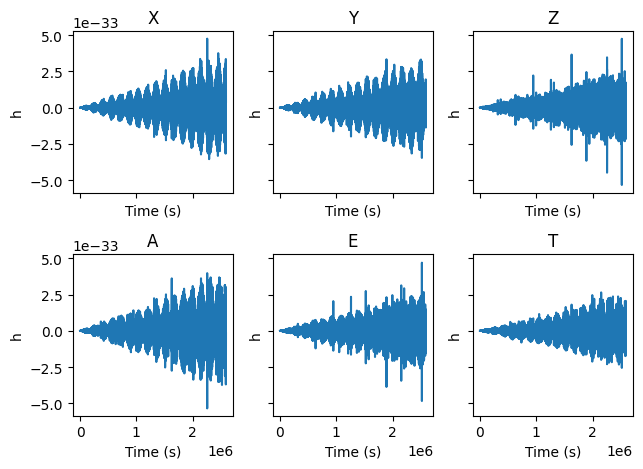

In [7]:
import time
import numpy as np
import matplotlib.pyplot as plt

try:
    import cupy as cp
except Exception:
    cp = None

from gwspace.Waveform import waveforms
from gwspace.constants import MONTH
from gwspace.response_gpu import (
    get_y_slr_td,
    get_XYZ_td,
    get_AET_td,
    tdi_XYZ2AET,
)

def to_cpu(x):
    return cp.asnumpy(x) if (cp is not None and isinstance(x, cp.ndarray)) else np.asarray(x)

def generate_td_data(pars, t_array, s_type="gcb", det="TQ", show_y_slr=False, use_gpu=True):
    print(f"Generating {s_type} waveforms")
    wf = waveforms[s_type](**pars)

    if show_y_slr:
        st = time.time()
        y_slr = get_y_slr_td(wf, t_array, det=det, use_gpu=use_gpu)
        ed = time.time()
        print(f"Time cost: {ed - st:.3f}s for {t_array.shape[0]} points")

        tags = [(1, 2), (2, 1), (1, 3), (3, 1), (2, 3), (3, 2)]
        for tag in tags:
            plt.figure()
            for j in range(4):
                plt.subplot(4, 1, j + 1)
                plt.plot(t_array, to_cpu(y_slr[tag][j]))
                plt.title(f"y_{tag} [{j}]L")

    st = time.time()
    X, Y, Z = get_XYZ_td(wf, t_array, det=det, TDIgen=1, use_gpu=use_gpu)
    A, E, T = tdi_XYZ2AET(X, Y, Z, use_gpu=use_gpu)
    ed = time.time()
    print(f"Time cost of calculating XYZ and AET with y_slr: {ed - st:.3f}s")

    plt.subplots(2, 3, sharex="all", sharey="all")
    for i, (d, label) in enumerate(zip((X, Y, Z, A, E, T), "XYZAET")):
        plt.subplot(2, 3, i + 1)
        plt.plot(t_array[:-5], to_cpu(d)[:-5])
        plt.xlabel("Time (s)")
        plt.ylabel("h")
        plt.title(label)
    plt.tight_layout()


# ------------------ EMRI 示例 ------------------
EMRIpars = {
    "M": 1e6,
    "mu": 1e1,
    "a": 0.1,
    "p0": 12.0,
    "e0": 0.2,
    "x0": 1.0,
    "qS": 0.3,
    "phiS": 0.3,
    "qK": 0.2,
    "phiK": 0.2,
    "dist": 1.0,
    "Phi_phi0": 1.0,
    "Phi_theta0": 2.0,
    "Phi_r0": 3.0,
    "psi": 0.4,
    "iota": 0.2,
    "T_obs": MONTH,
}

delta_t = 15.0  # seconds
tf = np.arange(0, EMRIpars["T_obs"], delta_t)

# waveform; get_hphc output may be CuPy if backend uses GPU, so convert before plotting
EMRIwf = waveforms["emri"](**EMRIpars)
hp, hc = EMRIwf.get_hphc(tf)
hp_cpu, hc_cpu = to_cpu(hp), to_cpu(hc)

# index = 2000
# plt.figure()
# plt.plot(tf[:index], hp_cpu[:index], label="h+")
# plt.plot(tf[:index], hc_cpu[:index], label="hx")
# plt.xlabel("Time (s)")
# plt.ylabel("h")
# plt.legend()
# plt.tight_layout()

# GPU-aware response (set use_gpu=False if no CuPy)
generate_td_data(EMRIpars, tf, s_type="emri", det="TQ", show_y_slr=False, use_gpu=True)


Backend: GPU (CuPy)
Generating gcb waveforms
Time cost: 4.045s for 1728000 points
Time cost of calculating XYZ and AET: 3.429s


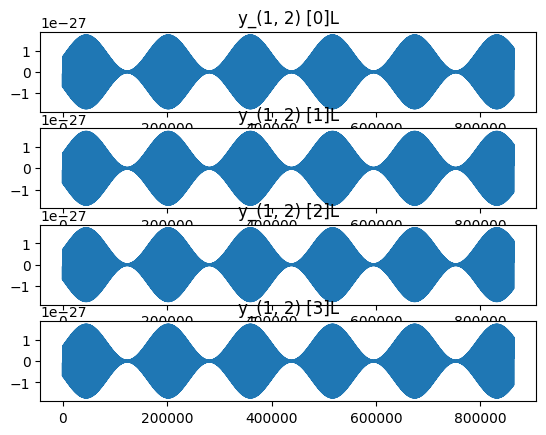

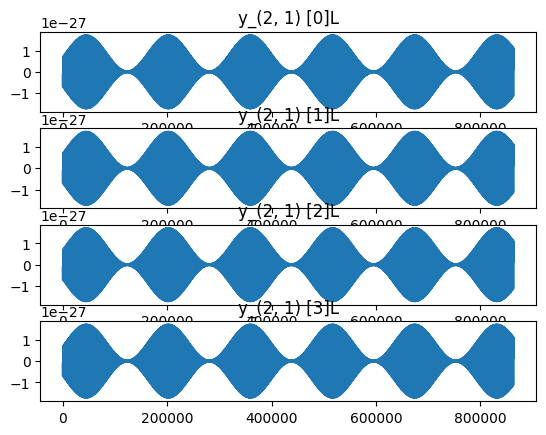

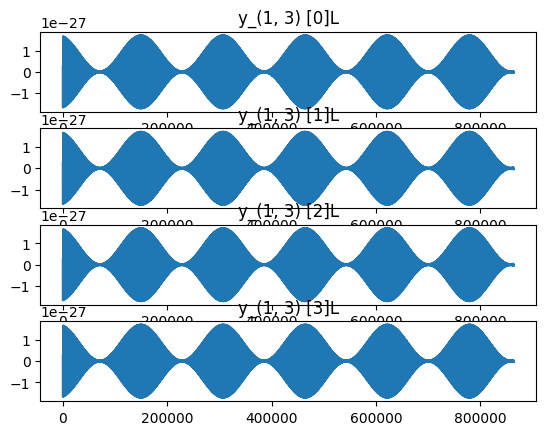

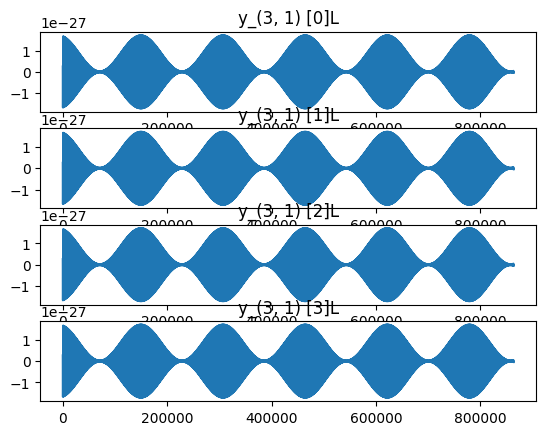

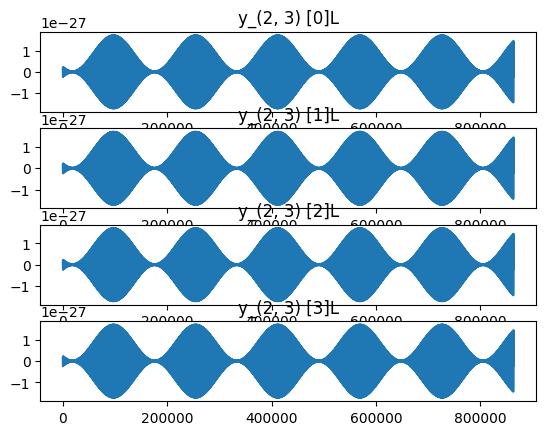

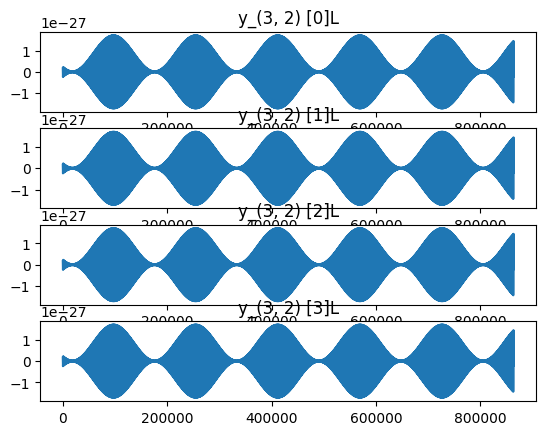

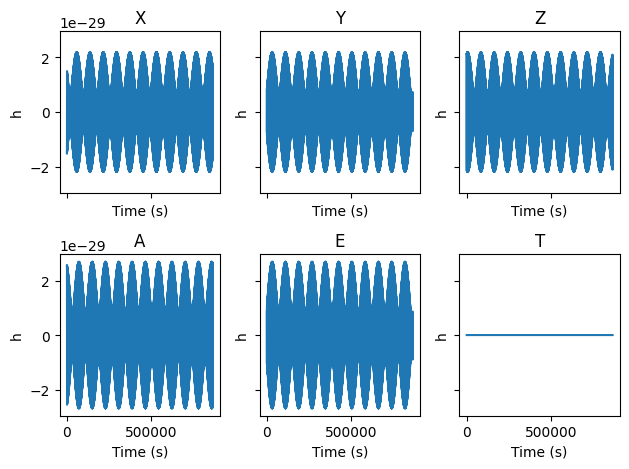

In [2]:
import time
import numpy as np
import matplotlib.pyplot as plt

try:
    import cupy as cp
except Exception:
    cp = None

from gwspace.Waveform import waveforms
from gwspace.constants import DAY
from gwspace.response_b import (
    get_y_slr_td,
    get_XYZ_td,
    get_AET_td,
    tdi_XYZ2AET,
)

def to_cpu(x):
    return cp.asnumpy(x) if (cp is not None and isinstance(x, cp.ndarray)) else np.asarray(x)

def generate_td_data(pars, t_array, s_type="gcb", det="TQ", show_y_slr=False, use_gpu=False):
    print(f"Backend: {'GPU (CuPy)' if use_gpu and cp is not None else 'CPU (NumPy)'}")
    print(f"Generating {s_type} waveforms")
    wf = waveforms[s_type](**pars)

    if show_y_slr:
        st = time.time()
        y_slr = get_y_slr_td(wf, t_array, det=det, use_gpu=use_gpu)
        ed = time.time()
        print(f"Time cost: {ed - st:.3f}s for {t_array.shape[0]} points")
        tags = [(1, 2), (2, 1), (1, 3), (3, 1), (2, 3), (3, 2)]
        for tag in tags:
            plt.figure()
            for j in range(4):
                plt.subplot(4, 1, j + 1)
                plt.plot(t_array, to_cpu(y_slr[tag][j]))
                plt.title(f"y_{tag} [{j}]L")

    st = time.time()
    X, Y, Z = get_XYZ_td(wf, t_array, det=det, TDIgen=1, use_gpu=use_gpu)
    A, E, T = tdi_XYZ2AET(X, Y, Z, use_gpu=use_gpu)  # or get_AET_td(wf, t_array, det=det, use_gpu=use_gpu)
    ed = time.time()
    print(f"Time cost of calculating XYZ and AET: {ed - st:.3f}s")

    plt.subplots(2, 3, sharex="all", sharey="all")
    for i, (d, label) in enumerate(zip((X, Y, Z, A, E, T), "XYZAET")):
        plt.subplot(2, 3, i + 1)
        plt.plot(t_array[:-5], to_cpu(d)[:-5])
        plt.xlabel("Time (s)")
        plt.ylabel("h")
        plt.title(label)
    plt.tight_layout()

# ------------------ GCB 示例 ------------------
GCBpars = {
    "mass1": 0.5,
    "mass2": 0.5,
    "DL": 0.3,
    "phi0": 0.0,
    "f0": 0.001,
    "psi": 0.2,
    "iota": 0.3,
    "Lambda": 0.4,
    "Beta": 1.2,
    "T_obs": 10 * DAY,
}

delta_t = 0.5  # seconds
tf = np.arange(0, GCBpars["T_obs"], delta_t)

GCBwf = waveforms["gcb"](**GCBpars)
hp, hc = GCBwf.get_hphc(tf)
hp_cpu, hc_cpu = to_cpu(hp), to_cpu(hc)

# Quick waveform plot (optional)
# plt.figure()
# plt.plot(tf[:4000], hp_cpu[:4000], label="h+")
# plt.plot(tf[:4000], hc_cpu[:4000], label="hx")
# plt.xlabel("Time (s)")
# plt.ylabel("h")
# plt.legend()
# plt.tight_layout()

# GPU-aware response (set use_gpu=True if you want to try CuPy)
generate_td_data(GCBpars, tf, s_type="gcb", det="TQ", show_y_slr=True, use_gpu=True)


Backend: CPU (NumPy)
Core y_slr time: 0.978s for 864000 points
Core XYZ+AET time: 0.885s


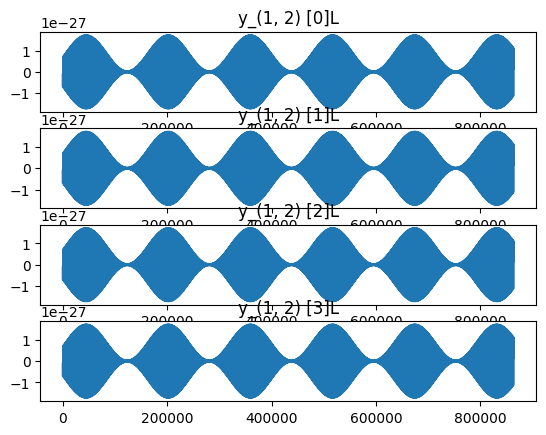

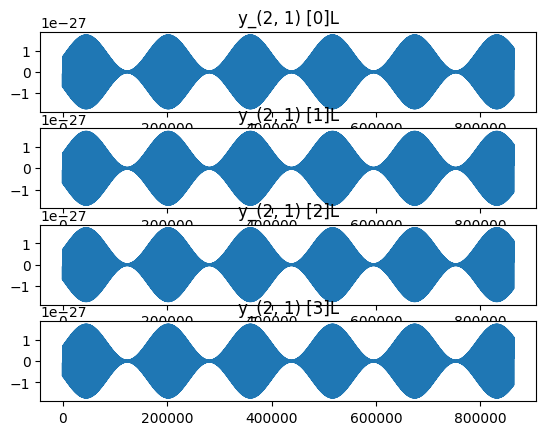

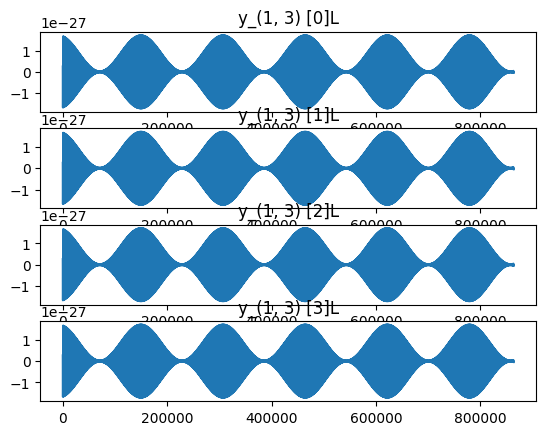

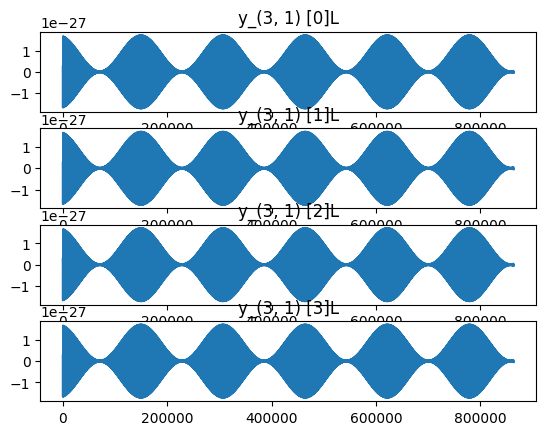

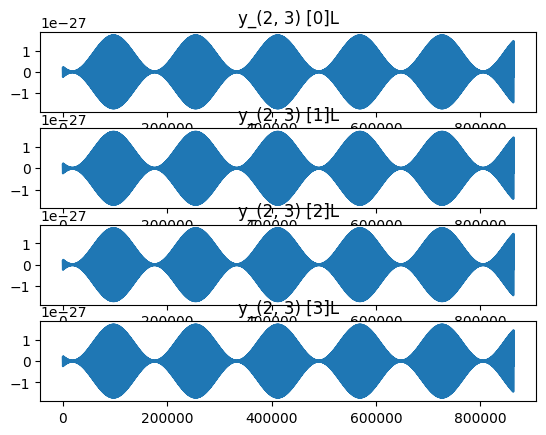

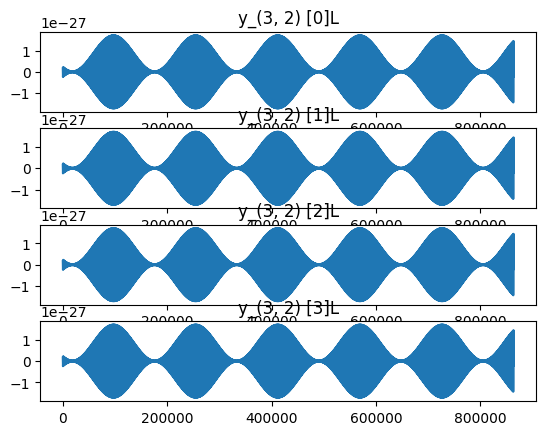

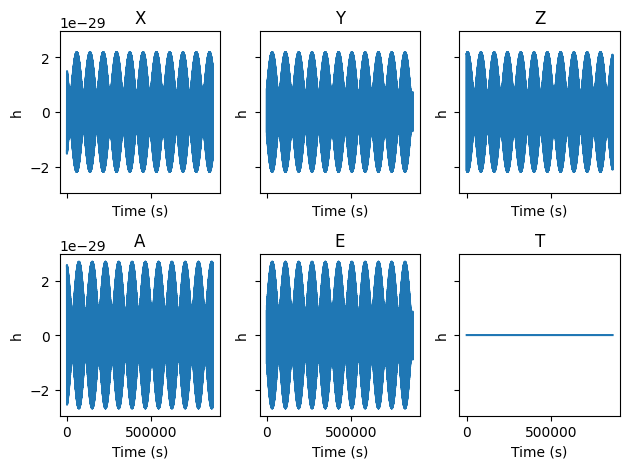

In [7]:
import time
import numpy as np
import matplotlib.pyplot as plt

try:
    import cupy as cp
except Exception:
    cp = None

from gwspace.Waveform import waveforms
from gwspace.constants import DAY
from gwspace.response_b import (
    get_y_slr_td,
    get_XYZ_td,
    get_AET_td,
    tdi_XYZ2AET,
)

def to_cpu(x):
    return cp.asnumpy(x) if (cp is not None and isinstance(x, cp.ndarray)) else np.asarray(x)

def generate_td_data(pars, t_array, s_type="gcb", det="TQ", show_y_slr=False, use_gpu=False):
    print(f"Backend: {'GPU (CuPy)' if use_gpu and cp is not None else 'CPU (NumPy)'}")
    wf = waveforms[s_type](**pars)

    # 只计 y_slr 核心计算
    if show_y_slr:
        st = time.perf_counter()
        y_slr = get_y_slr_td(wf, t_array, det=det, use_gpu=use_gpu)
        core_y_time = time.perf_counter() - st
        print(f"Core y_slr time: {core_y_time:.3f}s for {t_array.shape[0]} points")
        # 绘图不计时
        tags = [(1, 2), (2, 1), (1, 3), (3, 1), (2, 3), (3, 2)]
        for tag in tags:
            plt.figure()
            for j in range(4):
                plt.subplot(4, 1, j + 1)
                plt.plot(t_array, to_cpu(y_slr[tag][j]))
                plt.title(f"y_{tag} [{j}]L")

    # 只计 XYZ/AET 核心计算
    st = time.perf_counter()
    X, Y, Z = get_XYZ_td(wf, t_array, det=det, TDIgen=1, use_gpu=use_gpu)
    A, E, T = tdi_XYZ2AET(X, Y, Z, use_gpu=use_gpu)
    core_xyz_time = time.perf_counter() - st
    print(f"Core XYZ+AET time: {core_xyz_time:.3f}s")

    # 绘图不计时
    plt.subplots(2, 3, sharex="all", sharey="all")
    for i, (d, label) in enumerate(zip((X, Y, Z, A, E, T), "XYZAET")):
        plt.subplot(2, 3, i + 1)
        plt.plot(t_array[:-5], to_cpu(d)[:-5])
        plt.xlabel("Time (s)")
        plt.ylabel("h")
        plt.title(label)
    plt.tight_layout()

# ------------------ GCB 示例 ------------------
GCBpars = {
    "mass1": 0.5,
    "mass2": 0.5,
    "DL": 0.3,
    "phi0": 0.0,
    "f0": 0.001,
    "psi": 0.2,
    "iota": 0.3,
    "Lambda": 0.4,
    "Beta": 1.2,
    "T_obs": 10 * DAY,
}

delta_t = 1.0  # seconds
tf = np.arange(0, GCBpars["T_obs"], delta_t)

# 预热（可选，不计时）
_ = waveforms["gcb"](**GCBpars).get_hphc(tf)

generate_td_data(GCBpars, tf, s_type="gcb", det="TQ", show_y_slr=True, use_gpu=False)
